**Project Name:** Loan Approval Prediction — Bank Lending

**Problem Statement:** A bank receives loan applications and wants to automate the first-level screening — predicting whether a loan should be approved or rejected based on applicant details (income, credit history, employment, education, etc.). Build a Decision Tree classifier for this.

**Dataset:** [Loan-Approval-Prediction-Dataset (Kaggle)](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset) — real loan application data with `loan_status` as target. (Alternative if she wants the classic version: [Loan Prediction Dataset by ninzaami](https://www.kaggle.com/datasets/ninzaami/loan-predication).)

**Tech Stack:** Python, Pandas, NumPy, Matplotlib/Seaborn, Scikit-learn (`DecisionTreeClassifier`, `plot_tree`), Jupyter Notebook.

**Hints/Flow (make her reason, don't spoon-feed):**
1. EDA — check class balance of `loan_status` (approved vs rejected). Look at how income, credit history, and loan amount relate to approval.
2. Handle missing values — some categorical (fill with mode), some numeric (fill with median) — she should justify her choice per column, not blindly apply one method.
3. Encode categoricals (`Gender`, `Married`, `Education`, `Property_Area`, etc.) — Label Encoding is fine here since trees don't need one-hot (good teaching point: *why* trees don't require scaling or one-hot like linear/logistic models do).
4. No feature scaling needed — she should understand *why* (splits are threshold-based, not distance-based). This is the core conceptual contrast with her earlier logistic regression project.
5. Train a baseline `DecisionTreeClassifier()` with default params — check accuracy, then visualize the tree with `plot_tree()`. Is it huge and overfit?
6. Introduce `max_depth`, `min_samples_split`, `min_samples_leaf` — have her manually try a few values and observe train vs test accuracy gap (this teaches overfitting/pruning intuitively, no need for GridSearch yet, though she can add it as a stretch goal).
7. Feature importance — `.feature_importances_` — which factor drives approval most? Does it match her EDA intuition?

**Evaluation:** Accuracy, Precision, Recall, F1-score, Confusion Matrix. Bonus: compare a shallow tree vs deep tree's test performance to visually show the overfitting concept.

**Concept coverage checklist:** missing-value handling, encoding, no-scaling rationale, entropy/Gini split intuition (she can just read theory on this, no need to code from scratch), overfitting & pruning via hyperparameters, feature importance, evaluation metrics.

1. Import Libraries
2. Load Dataset
3. Dataset Information
4. EDA
5. Missing Value Handling
6. Duplicate Check
7. Target Variable Analysis
8. Data Visualization
9. Remove Loan ID
10. Label Encoding
11. Define X and y
12. Train-Test Split
13. Decision Tree Baseline
14. Prediction
15. Accuracy
16. Precision
17. Recall
18. F1 Score
19. Classification Report
20. Confusion Matrix
21. Decision Tree Visualization
22. Overfitting Analysis
23. max_depth
24. min_samples_split
25. min_samples_leaf
26. Feature Importance
27. Final Model
28. New Prediction
29. Conclusion

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import plot_tree

In [8]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (3)\loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [9]:
df.shape

(4269, 13)

In [10]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [12]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [13]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()
df


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [18]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [20]:
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

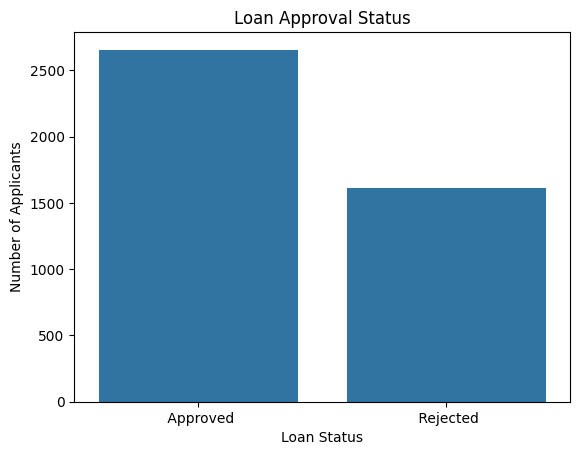

In [22]:
# Visualize Loan Status
sns.countplot(x=' loan_status', data=df)

plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

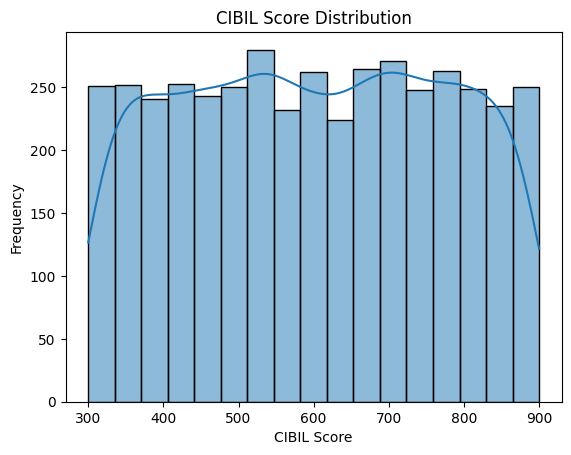

In [24]:
# Check CIBIL Score
sns.histplot(df[' cibil_score'], kde=True)

plt.title("CIBIL Score Distribution")
plt.xlabel("CIBIL Score")
plt.ylabel("Frequency")

plt.show()

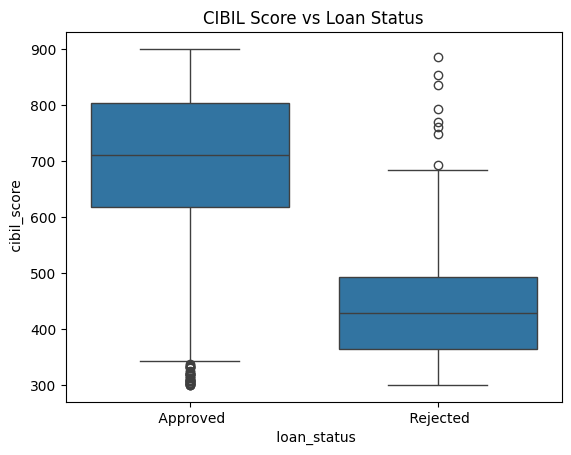

In [26]:
# CIBIL Score vs Loan Status
sns.boxplot(x=' loan_status', y=' cibil_score', data=df)

plt.title("CIBIL Score vs Loan Status")
plt.show()

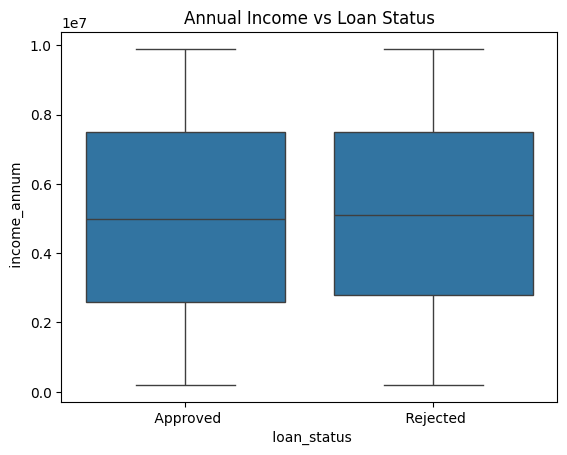

In [28]:
# Income vs Loan Status
sns.boxplot(x=' loan_status', y=' income_annum', data=df)

plt.title("Annual Income vs Loan Status")
plt.show()

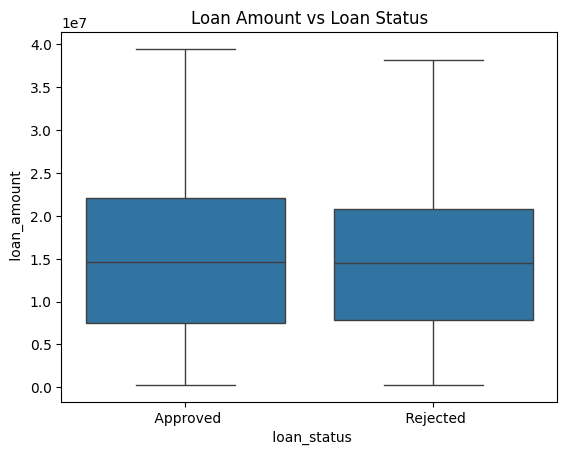

In [30]:
# Loan Amount vs Loan Status
sns.boxplot(x=' loan_status', y=' loan_amount', data=df)

plt.title("Loan Amount vs Loan Status")
plt.show()

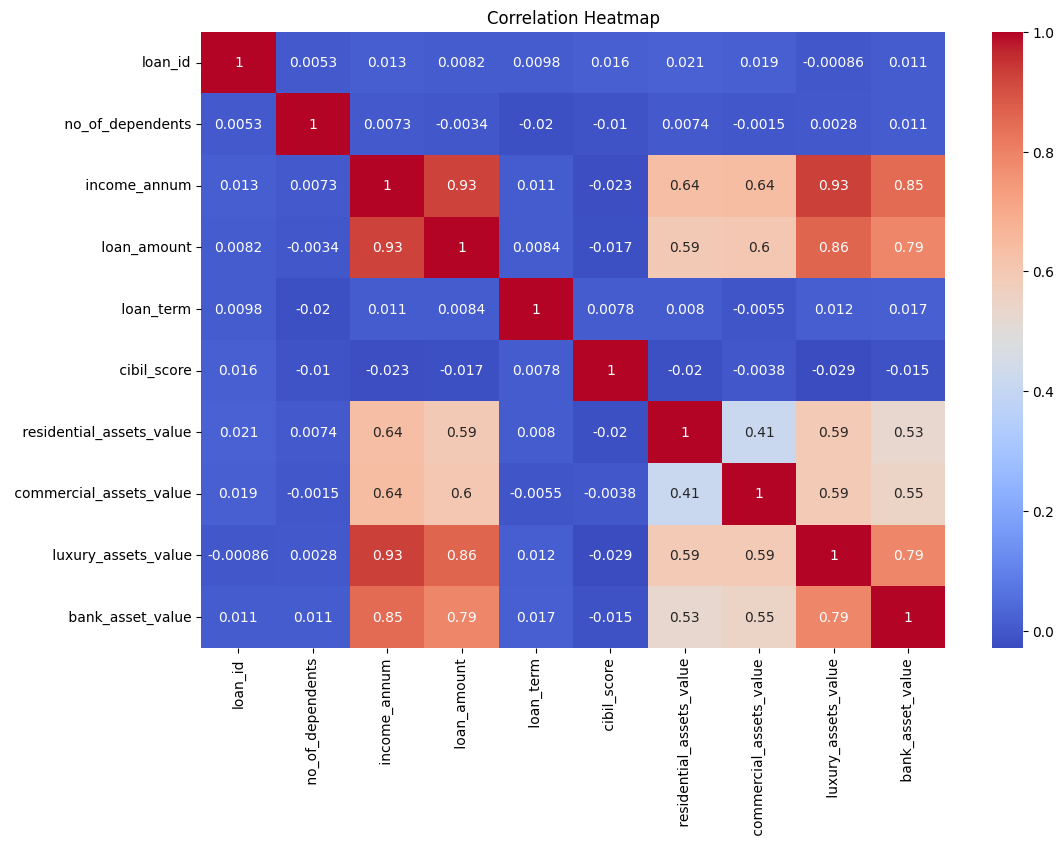

In [32]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [34]:
# Check Categorical Columns
df[' education'].value_counts()

 education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [35]:
df[' self_employed'].value_counts()

 self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [40]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check columns
print(df.columns.tolist())

# Remove Loan ID
df = df.drop('loan_id', axis=1, errors='ignore')

# Check data
df.head()

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [42]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [43]:
# Convert Categorical Columns
df_encoded = df.copy()

In [45]:
le = LabelEncoder()

df_encoded['education'] = le.fit_transform(df_encoded['education'])
df_encoded['self_employed'] = le.fit_transform(df_encoded['self_employed'])
df_encoded['loan_status'] = le.fit_transform(df_encoded['loan_status'])

In [47]:
df_encoded.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [48]:
# Separate X and y
X = df_encoded.drop('loan_status', axis=1)

y = df_encoded['loan_status']

In [49]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4269, 11)
y shape: (4269,)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3415, 11)
X_test: (854, 11)
y_train: (3415,)
y_test: (854,)


In [53]:
#no scaling in decision tree

In [54]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [55]:
y_pred = model.predict(X_test)

In [56]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9718969555035128


In [57]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9718969555035128


In [58]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9746031746031746


In [59]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9504643962848297


In [60]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9623824451410659


In [61]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9718969555035128
Precision: 0.9746031746031746
Recall   : 0.9504643962848297
F1 Score : 0.9623824451410659


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       531
           1       0.97      0.95      0.96       323

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [63]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[523   8]
 [ 16 307]]


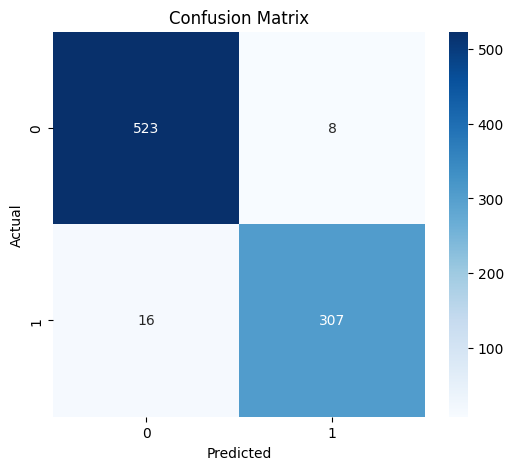

In [64]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

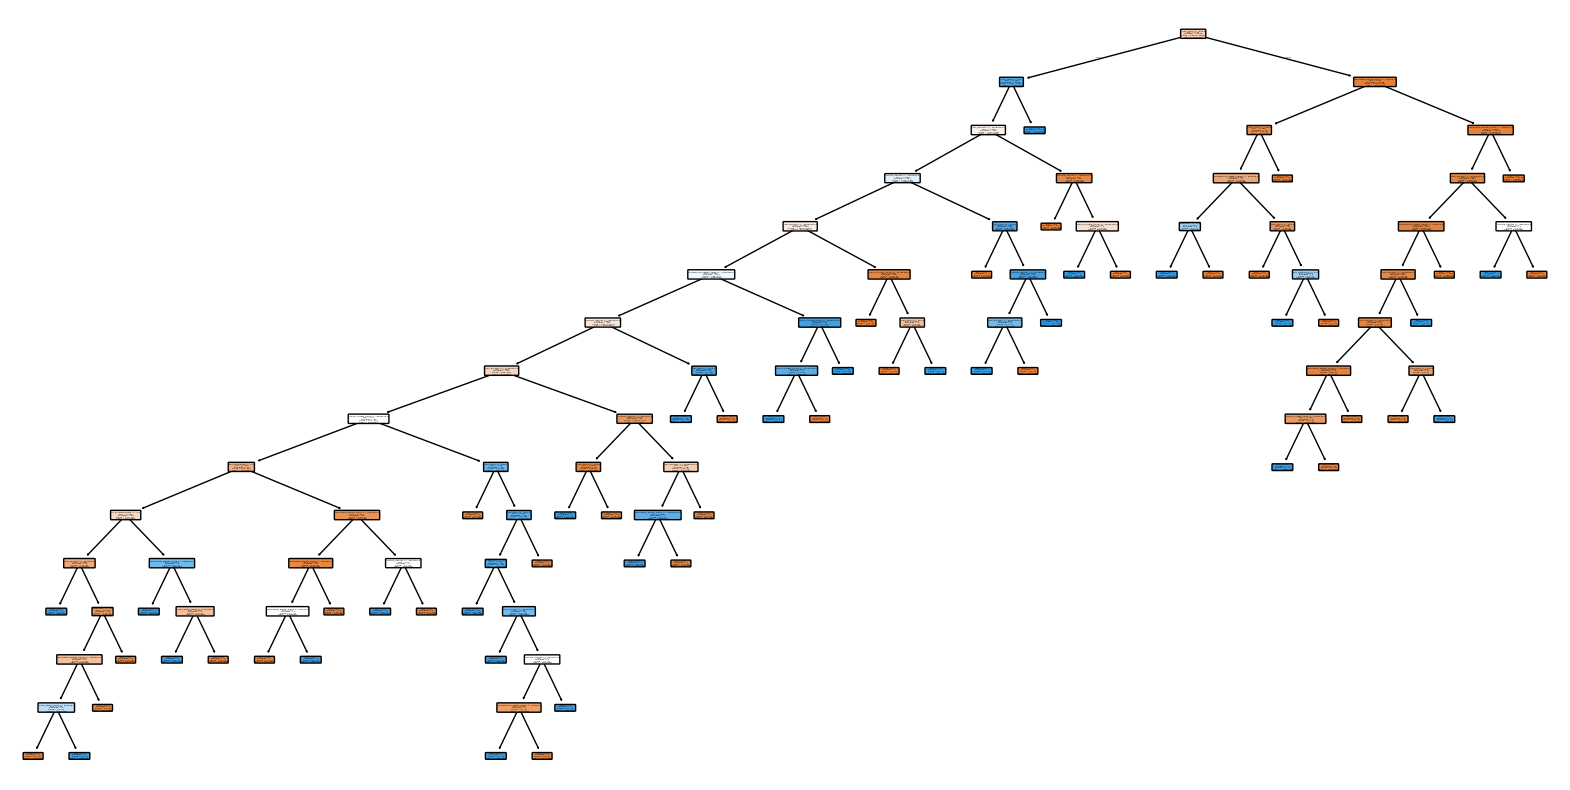

In [65]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True
)

plt.show()

In [66]:
# Create Shallow Decision Tree
model2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [67]:
y_pred2 = model2.predict(X_test)

In [68]:
train_accuracy2 = accuracy_score(
    y_train,
    model2.predict(X_train)
)

test_accuracy2 = accuracy_score(
    y_test,
    y_pred2
)

print("Training Accuracy:", train_accuracy2)
print("Testing Accuracy:", test_accuracy2)

Training Accuracy: 0.9727672035139092
Testing Accuracy: 0.9765807962529274


In [69]:
# Try Different max_depth
depths = [2, 3, 4, 5, 6, 8, 10]

for depth in depths:
    
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    
    print(
        "Depth:", depth,
        "Train:", round(train_acc, 3),
        "Test:", round(test_acc, 3)
    )

Depth: 2 Train: 0.957 Test: 0.961
Depth: 3 Train: 0.962 Test: 0.972
Depth: 4 Train: 0.968 Test: 0.968
Depth: 5 Train: 0.973 Test: 0.977
Depth: 6 Train: 0.979 Test: 0.972
Depth: 8 Train: 0.984 Test: 0.979
Depth: 10 Train: 0.994 Test: 0.974


In [71]:
# min_samples_split
model3 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

model3.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [72]:
# min_samples_leaf
model4 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model4.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [73]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model4.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,cibil_score,0.875809
5,loan_term,0.088993
4,loan_amount,0.021455
3,income_annum,0.012075
9,luxury_assets_value,0.000883
7,residential_assets_value,0.000610
8,commercial_assets_value,0.000175
2,self_employed,0.000000
1,education,0.000000
0,no_of_dependents,0.000000


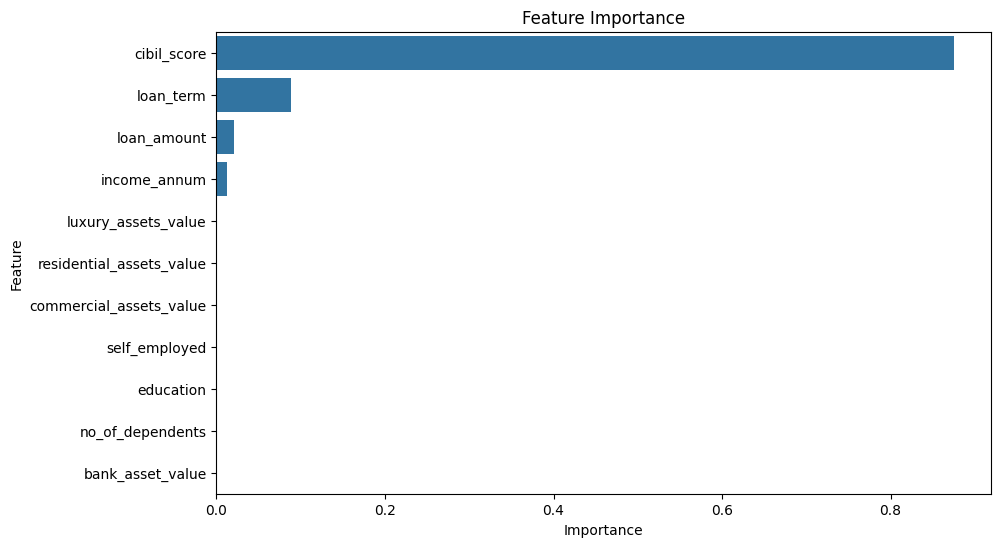

In [75]:
# Feature Importance Graph
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

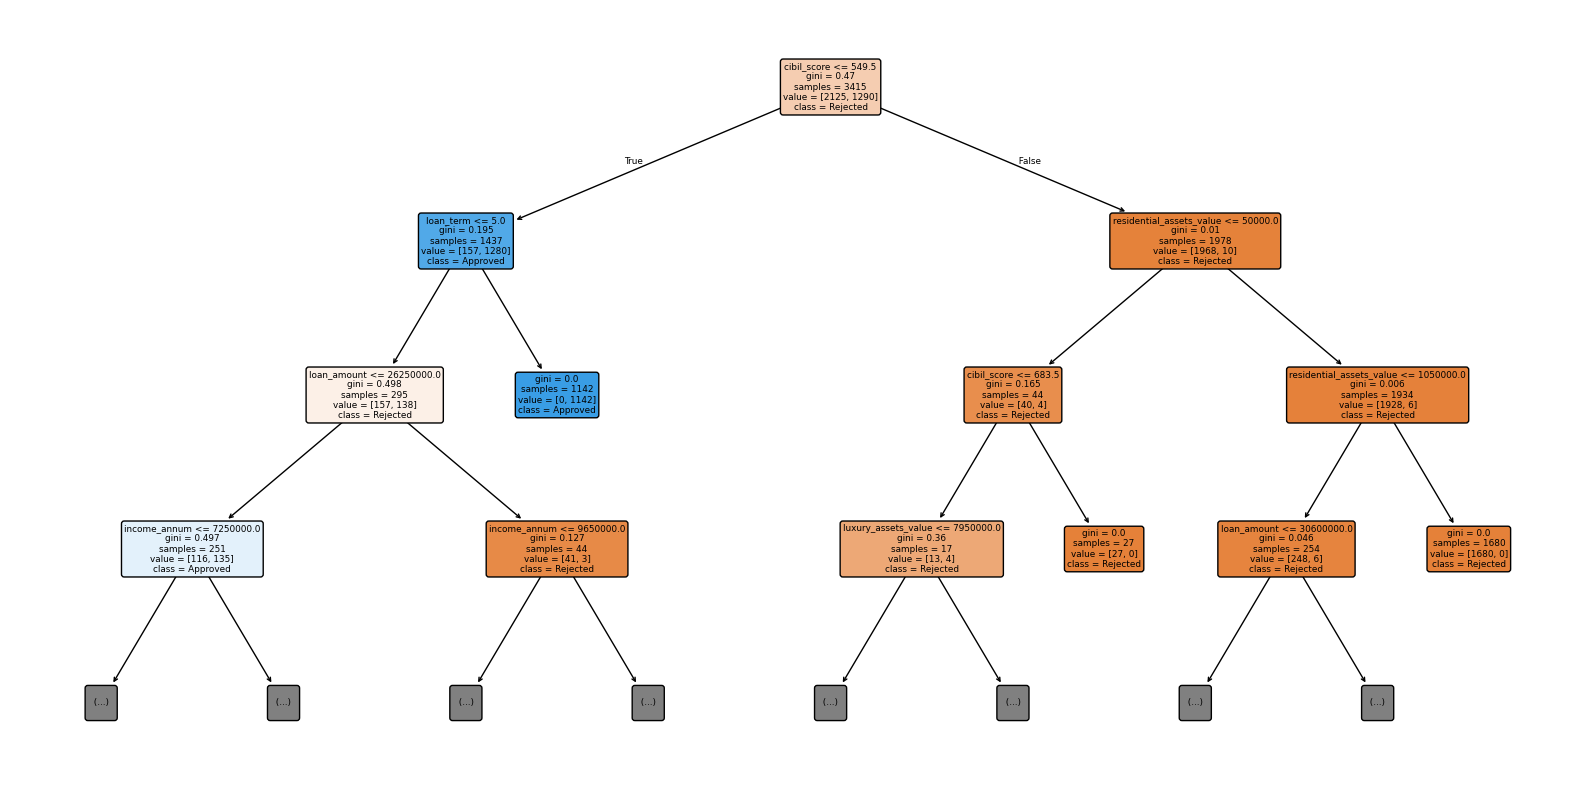

In [77]:
# Visualize Final Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model4,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

In [79]:
# Final Model Evaluation
final_pred = model4.predict(X_test)

print("Final Model Performance")
print("-----------------------")

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))

Final Model Performance
-----------------------
Accuracy : 0.9789227166276346
Precision: 0.9552238805970149
Recall   : 0.9907120743034056
F1 Score : 0.9726443768996961


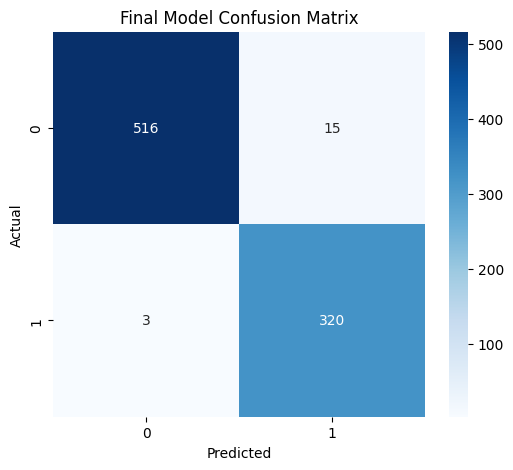

In [80]:
# Final Confusion Matrix
final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")

plt.show()


In [82]:
# Predict a New Applicant
new_applicant = pd.DataFrame({
    'no_of_dependents': [2],
    'education': [1],
    'self_employed': [0],
    'income_annum': [8000000],
    'loan_amount': [20000000],
    'loan_term': [15],
    'cibil_score': [750],
    'residential_assets_value': [5000000],
    'commercial_assets_value': [2000000],
    'luxury_assets_value': [3000000],
    'bank_asset_value': [4000000]
})

In [83]:
prediction = model4.predict(new_applicant)

print(prediction)

[0]


In [85]:
# Check Label Mapping
print(le.classes_)

[0 1]


In [86]:
if prediction[0] == 0:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


Conclusion:
In this project, I built a Decision Tree classifier to predict loan approval status. I performed data cleaning, exploratory data analysis, categorical encoding, train-test splitting, and model evaluation. I used accuracy, precision, recall, F1-score, and confusion matrix to evaluate the model. I also controlled overfitting using parameters such as max_depth, min_samples_split, and min_samples_leaf. Feature importance helped identify the variables that contributed most to the model's predictions.